# AAPI candidate availability — coalition VAP boxplots

Adapted from the Chicago project's coalition boxplot
(`plot_coalition_boxplot_available` in that repo's `pipeline/summarize_results.py`),
re-pointed at San Diego's blocs, slates, and settings layout.

**What it shows.** Every district in every sampled plan is ranked by the focal
group's share of district VAP, low to high, *within its own plan*. Rank 1 is that
plan's lowest-AAPI district, rank 9 its highest. Raw district ids aren't
comparable across plans — district 5 in plan 0 is not the same geography as
district 5 in plan 200 — but rank position is, so the ranks pool across all 100
plans. Each box is one rank's distribution of AAPI VAP share.

**What the colour means.** Chicago filled each box by that rank's *win rate*.
Here the fill is **candidate availability**: the share of plans at that rank where
the AAPI slate was apportioned at least one candidate. A rank no plan ever put an
AAPI candidate in is filled solid black, so "never on the ballot" reads as
categorically different from "rarely".

`settings_generator` drops a slate from `slate_to_candidates` entirely when it
draws zero candidates for a district, so that absence *is* the datum — the same
signal Chicago used for its availability filter, promoted here from a filter to
the thing being measured.

**Every settings file, no filter.** Because availability is what's being shown,
the boxes cover all (plan, district) pairs rather than the availability-restricted
subset, and every rank carries the full 100 plans. The win-rate variant further
down keeps Chicago's restriction for the cases where that reading is wanted.

In [8]:
import json
import random
import re
import sys
import zipfile
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

from pipeline.summarize_results import (  # noqa: E402
    BAR_EDGE_COLOR,
    LEGEND_MAPPING,
    _method_label,
    _rule_display_name,
)
from pipeline.settings_generator import minimum_candidates  # noqa: E402
from pipeline.utils.helpers import (  # noqa: E402
    load_run_config,
    load_json,
    parse_plan_district_rep_from_path,
)

# Which run to read. Every completed run under outputs/ is fair game; the
# alternative-systems run is the interesting one because it carries six voting
# systems, so the win-rate coloring differs rule by rule.
CONFIG_NAME = "configs/alternative_electoral.json"

# The two-round family: a narrowing round followed by a deciding round. Alaska
# and Top Two are VoteKit's built-ins, which derive round 2 by stripping their
# round-1 ballots; the *TwoProfile pair resample a fresh round-2 profile instead
# (see pipeline/two_round_election.py). Set to None to cover every system.
SYSTEMS_OF_INTEREST = ["ALASKA", "ALASKATWOPROFILE", "TOPTWO", "TOPTWOTWOPROFILE"]

config = load_run_config(PROJECT_DIR / CONFIG_NAME)
RUN_NAME = config["run_name"]
FOCAL = config["focal_group"]
SUMMARY_CSV = PROJECT_DIR / "outputs" / RUN_NAME / "summaries" / f"{RUN_NAME}_summary.csv"

summary = pd.read_csv(SUMMARY_CSV)
print(f"{RUN_NAME}: {len(summary):,} district-level rows")
print("focal group:", FOCAL)
print("voting systems:", sorted(summary["election_method"].unique()))
print("voter models:", sorted(summary["mode"].unique()), "(pooled, not sliced)")
print("candidate floor for this run:", minimum_candidates(config))

systems = [s for s in SYSTEMS_OF_INTEREST if s in set(summary["election_method"])] \
    if SYSTEMS_OF_INTEREST else sorted(summary["election_method"].unique())
missing = sorted(set(SYSTEMS_OF_INTEREST or []) - set(summary["election_method"]))
print("systems in scope:", systems)
if missing:
    print("not in this run (skipped):", missing)

Alternative Electoral Systems: 108,000 district-level rows
focal group: AAPI
voting systems: ['ALASKA', 'ALASKATWOPROFILE', 'IRV', 'PLURALITY', 'TOPTWO', 'TOPTWOTWOPROFILE']
voter models: ['slate_bt', 'slate_pl'] (pooled, not sliced)
candidate floor for this run: 4
systems in scope: ['ALASKA', 'ALASKATWOPROFILE', 'TOPTWO', 'TOPTWOTWOPROFILE']


## Reading the district facts out of the settings files

Both inputs are demographic/structural facts about a district, independent of
voter model and replicate, so they're read once per (plan, district) from the
settings JSON rather than off the per-simulation summary rows.

One adaptation from Chicago: San Diego's settings already store a combined
`group_vap` map, so a multi-column group like `BAIO` (Black + American Indian +
other) is summed upstream by `settings_generator` instead of being re-derived
here. That keeps this notebook agreeing with the pipeline by construction.

In [9]:
def load_district_vap_shares(config, district_count: int) -> pd.DataFrame:
    """Per-(plan, district) VAP share for every bloc, straight from the settings files."""
    settings_dir = PROJECT_DIR / "outputs" / config["run_name"] / "settings" / str(district_count)
    if not settings_dir.is_dir():
        return pd.DataFrame()

    total_vap_col = config["population_vap_column"]
    rows = []
    for settings_path in sorted(settings_dir.glob("*.json")):
        plan, district, _ = parse_plan_district_rep_from_path(settings_path.name)
        if plan is None or district is None:
            continue
        data = load_json(settings_path)
        total_vap = data.get(total_vap_col)
        row = {"plan": plan, "district_id": district}
        for group, vap in (data.get("group_vap") or {}).items():
            row[group] = (vap / total_vap) if total_vap else 0.0
        rows.append(row)
    return pd.DataFrame(rows)


def load_district_candidate_availability(config, district_count: int, slate: str) -> pd.DataFrame:
    """
    Per-(plan, district) how many `slate` candidates were on the ballot.

    settings_generator drops a slate from slate_to_candidates when it draws zero
    candidates for that district, so its absence there means a count of zero.
    `n_candidates` is the figure's colour metric; `has_candidate` is kept for the
    win-rate section, which restricts to contestable districts.
    """
    settings_dir = PROJECT_DIR / "outputs" / config["run_name"] / "settings" / str(district_count)
    if not settings_dir.is_dir():
        return pd.DataFrame()

    rows = []
    for settings_path in sorted(settings_dir.glob("*.json")):
        plan, district, _ = parse_plan_district_rep_from_path(settings_path.name)
        if plan is None or district is None:
            continue
        data = load_json(settings_path)
        candidates = data.get("slate_to_candidates", {}).get(slate, [])
        rows.append({
            "plan": plan,
            "district_id": district,
            "n_candidates": len(candidates),
            "has_candidate": bool(candidates),
        })
    return pd.DataFrame(rows)


district_counts = sorted(summary["num_districts"].unique())
vap_by_count = {n: load_district_vap_shares(config, int(n)) for n in district_counts}
avail_by_count = {n: load_district_candidate_availability(config, int(n), FOCAL) for n in district_counts}

for n in district_counts:
    avail = avail_by_count[n]
    total = int(avail["n_candidates"].sum()) if not avail.empty else 0
    share = avail["has_candidate"].mean() if not avail.empty else float("nan")
    print(f"{n} districts: {len(vap_by_count[n]):,} (plan, district) pairs | "
          f"{total:,} {FOCAL} candidates fielded | at least one in {share:.1%} of districts")

9 districts: 900 (plan, district) pairs | 752 AAPI candidates fielded | at least one in 46.6% of districts


## Ranking and pooling

`rank_districts` is the piece that carries the subtlety: it ranks against the
full plan and only then drops the rows outside `restrict_to`.

In [10]:
def rank_districts(vap_df: pd.DataFrame, group: str, restrict_to: pd.DataFrame | None = None) -> pd.DataFrame:
    """Rank each plan's districts by `group` VAP share (ascending, 1 = lowest)."""
    ranked = vap_df.copy()
    ranked["vap_rank"] = ranked.groupby("plan")[group].rank(method="first").astype(int)
    if restrict_to is not None:
        ranked = ranked.merge(
            restrict_to[["plan", "district_id"]], on=["plan", "district_id"], how="inner"
        )
    return ranked


def rank_boxplot_data(district_df, vap_df, group, restrict_to=None):
    """
    Returns (data_by_rank, win_rate_by_rank): VAP-share percentages pooled by
    rank, and the share of (plan, district, replicate) instances at that rank
    where the group's slate took at least one seat.
    """
    seat_col = f"seats_{group}"
    if group not in vap_df.columns or seat_col not in district_df.columns:
        return {}, pd.Series(dtype=float)

    ranked = rank_districts(vap_df, group, restrict_to=restrict_to)
    merged = district_df[["plan", "district_id", seat_col]].merge(
        ranked[["plan", "district_id", "vap_rank"]], on=["plan", "district_id"], how="inner"
    )
    if merged.empty:
        return {}, pd.Series(dtype=float)

    win_rate_by_rank = merged.groupby("vap_rank")[seat_col].apply(lambda s: (s > 0).mean() * 100)
    data_by_rank = {
        r: (ranked.loc[ranked["vap_rank"] == r, group].to_numpy() * 100)
        for r in sorted(ranked["vap_rank"].unique())
    }
    return data_by_rank, win_rate_by_rank

## Drawing

The gradient is green on purpose: it encodes win rate, not a voter model, and
the project's gold/red are already spoken for by Impulsive/Deliberative
everywhere else. A rank that never elected the slate is filled solid black
rather than the palest green, so "never" reads as categorically different from
"rarely" instead of blending into the bottom of the ramp.

In [11]:
COALITION_BASE_COLOR = "#1a7a3c"
COALITION_NO_WINNER_COLOR = "#000000"


def draw_coalition_boxplot(ax, data_by_rank, color_by_rank, group_label, zero_case_label=None):
    ranks = sorted(data_by_rank)
    data = [data_by_rank[r] for r in ranks]
    zero_case_label = zero_case_label or f"No {group_label} winner at this rank"

    nonzero = color_by_rank[color_by_rank > 0]
    cmap = mcolors.LinearSegmentedColormap.from_list("winrate", ["#ffffff", COALITION_BASE_COLOR])
    norm = (
        mcolors.Normalize(vmin=0, vmax=1)
        if nonzero.empty
        else mcolors.Normalize(vmin=nonzero.min(), vmax=nonzero.max())
    )

    bp = ax.boxplot(
        data,
        positions=ranks,
        patch_artist=True,
        widths=0.6,
        medianprops={"color": "#0b0b0b", "linewidth": 1},
        whiskerprops={"color": BAR_EDGE_COLOR, "linewidth": 1},
        capprops={"color": BAR_EDGE_COLOR, "linewidth": 1},
        flierprops={
            "marker": "o", "markersize": 3,
            "markerfacecolor": "#898781", "markeredgecolor": "none", "alpha": 0.5,
        },
    )
    for patch, median, r in zip(bp["boxes"], bp["medians"], ranks):
        rate = color_by_rank.get(r, 0.0)
        no_signal = rate <= 0
        patch.set_facecolor(COALITION_NO_WINNER_COLOR if no_signal else cmap(norm(rate)))
        patch.set_edgecolor(BAR_EDGE_COLOR)
        patch.set_linewidth(0.9)
        # The near-black median would vanish against a solid-black box.
        if no_signal:
            median.set_color("#ffffff")

    overall_mean = float(np.mean(np.concatenate(data)))
    mean_line = ax.axhline(
        overall_mean, color="#0b0b0b", linestyle=":", linewidth=1.2,
        label=f"Mean VAP share: {overall_mean:.1f}%",
    )
    ax.legend(
        handles=[
            mean_line,
            Patch(facecolor=COALITION_NO_WINNER_COLOR, edgecolor=BAR_EDGE_COLOR, label=zero_case_label),
        ],
        loc="upper left", fontsize=8, frameon=True,
    )

    ax.set_xlabel(f"Districts ranked by {group_label} VAP share (low to high)", fontsize=9)
    ax.set_ylabel(f"{group_label} % of district VAP", fontsize=9)
    ax.set_xticks(ranks)
    ax.set_xticklabels([str(r) for r in ranks], fontsize=7)
    ax.set_xlim(min(ranks) - 0.7, max(ranks) + 0.7)
    ax.grid(axis="y", linewidth=0.5, color="#e1e0d9", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)


def add_coalition_colorbar(fig, rect, color_by_rank, label="Win rate", tick_fmt="{:.0f}%"):
    """
    Small horizontal colorbar, labeled only at the two extreme nonzero values.

    tick_fmt controls how those two endpoints read -- "{:.0f}%" for a rate,
    "{:.0f}" for a raw count.
    """
    nonzero = color_by_rank[color_by_rank > 0]
    if nonzero.empty:
        return
    cmap = mcolors.LinearSegmentedColormap.from_list("winrate", ["#ffffff", COALITION_BASE_COLOR])
    sm = ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=nonzero.min(), vmax=nonzero.max()))
    cbar = fig.colorbar(sm, cax=fig.add_axes(rect), orientation="horizontal")
    cbar.set_ticks([nonzero.min(), nonzero.max()])
    cbar.set_label(label, fontsize=8)
    cbar.ax.xaxis.set_label_position("top")
    cbar.set_ticklabels([tick_fmt.format(nonzero.min()), tick_fmt.format(nonzero.max())])
    cbar.ax.tick_params(labelsize=7, length=0)
    cbar.outline.set_visible(False)

## Availability by rank

`candidates_by_rank` is the colour metric: the **average number of AAPI
candidates on the ballot per district** at this rank. A value of 0.5 means one
candidate in every other district at that rank; 2.5 means most districts there
fielded a slate of two or three. The colorbar is anchored at the smallest and
largest averages any rank recorded, so the ramp spans the range the run actually
produced.

Averaging per district rather than summing keeps the number independent of how
many plans were sampled — a 1,000-plan run reads on the same scale as this
100-plan one. A rank where the slate never fielded anyone averages zero and is
filled solid black.

It needs no election results: availability is settled when the settings files are
written, before a single ballot is cast.

That has a consequence worth stating plainly: **availability does not vary by
voting system.** Each district's slate sizes are drawn once and shared by every
rule the run simulates, so an availability figure for Alaska is the same figure as
for Top Two. What the two-round rules *do* affect is the floor: `minimum_candidates`
takes the most demanding requirement in the run, and Alaska's `m_1 = 4` sets it to
4 candidates per district here. That floor lifts availability everywhere, which is
part of why the low ranks are not emptier than they are.

So this section draws one figure per district configuration, not per system. The
win-rate section below is where the systems differ, and that one is drawn per
system.

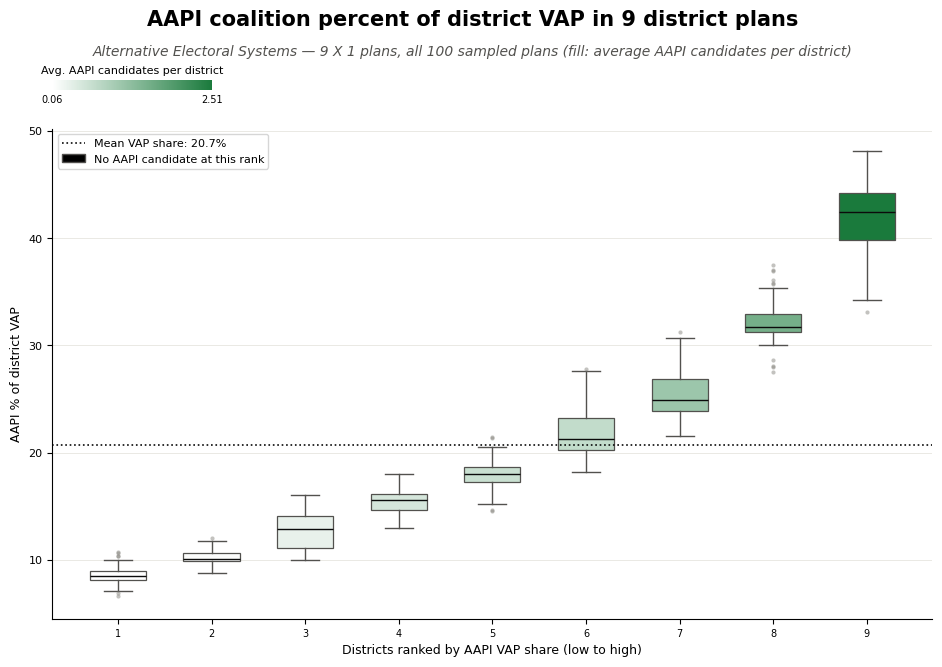

In [12]:
def candidates_by_rank(num_dist, slate=None):
    """
    Average number of `slate` candidates on the ballot per district at each rank.

    Ranks over every district in every plan -- no restriction -- so each rank
    covers all sampled plans. Averaging per district rather than summing keeps
    the number independent of how many plans were sampled: 0.5 means one
    candidate in every other district at that rank, whether the run drew 100
    plans or 1,000.
    """
    slate = slate or FOCAL
    vap_df, avail_df = vap_by_count[num_dist], avail_by_count[num_dist]
    ranked = rank_districts(vap_df, slate)
    merged = ranked[["plan", "district_id", "vap_rank", slate]].merge(
        avail_df, on=["plan", "district_id"], how="inner"
    )
    data_by_rank = {
        r: (merged.loc[merged["vap_rank"] == r, slate].to_numpy() * 100)
        for r in sorted(merged["vap_rank"].unique())
    }
    count_by_rank = merged.groupby("vap_rank")["n_candidates"].mean()
    return data_by_rank, count_by_rank


def plot_availability_boxplot(num_dist, seats_per_district, save_dir=None):
    """Boxes = AAPI VAP share by rank; fill = share of plans with a candidate."""
    data_by_rank, count_by_rank = candidates_by_rank(num_dist)
    if not data_by_rank:
        print("no settings data for", num_dist, "districts")
        return None

    fig = plt.figure(figsize=(max(10.0, len(data_by_rank) * 0.9), 7))
    ax = fig.add_axes((0.08, 0.10, 0.88, 0.70))
    draw_coalition_boxplot(
        ax, data_by_rank, count_by_rank, FOCAL,
        zero_case_label=f"No {FOCAL} candidate at this rank",
    )

    fig.suptitle(
        f"{FOCAL} coalition percent of district VAP in {num_dist} district plans",
        fontsize=15, fontweight="bold", y=0.97,
    )
    fig.text(
        0.5, 0.90,
        f"{RUN_NAME} — {num_dist} X {seats_per_district} plans, all {vap_by_count[num_dist]['plan'].nunique()} "
        f"sampled plans (fill: average {FOCAL} candidates per district)",
        ha="center", va="bottom", fontsize=10, color="#52514e", style="italic",
    )
    add_coalition_colorbar(
        fig, (0.08, 0.855, 0.16, 0.015), count_by_rank,
        label=f"Avg. {FOCAL} candidates per district", tick_fmt="{:.2f}",
    )

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out = save_dir / f"{RUN_NAME}_{num_dist}x{seats_per_district}_{FOCAL}_candidate_availability.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("wrote", out)
    return fig


configs_in_run = (
    summary[["num_districts", "seats_per_district"]].drop_duplicates().astype(int).values.tolist()
)
for n, w in configs_in_run:
    fig = plot_availability_boxplot(n, w)
    if fig is not None:
        plt.show()

## The numbers behind the colours

Availability climbs steeply with AAPI VAP share, which is the intended effect of
the exaggerated apportionment in `settings_generator._build_slate_to_candidates`:
each district's slate sizes are drawn in proportion to squared VAP shares, so a
small AAPI share becomes a much smaller chance of fielding anyone.

`candidates_per_district` is what the colour encodes. The other columns are kept
for reference — a rank can reach the same average either because most plans
fielded exactly one candidate, or because a minority fielded several.

In [13]:
def availability_table(num_dist):
    vap_df, avail_df = vap_by_count[num_dist], avail_by_count[num_dist]
    ranked = rank_districts(vap_df, FOCAL)
    merged = ranked[["plan", "district_id", "vap_rank", FOCAL]].merge(
        avail_df, on=["plan", "district_id"], how="inner"
    )
    out = merged.groupby("vap_rank").agg(
        plans=("plan", "nunique"),
        candidates=("n_candidates", "sum"),
        districts_with_any=("has_candidate", "sum"),
        candidates_per_district=("n_candidates", "mean"),
        availability_pct=("has_candidate", lambda s: s.mean() * 100),
        **{f"mean_{FOCAL}_vap_pct": (FOCAL, lambda s: s.mean() * 100)},
    )
    return out.round(2)


for n, w in configs_in_run:
    print(f"=== {RUN_NAME}: {n} X {w} ===")
    print(availability_table(n).to_string(), "\n")

=== Alternative Electoral Systems: 9 X 1 ===
          plans  candidates  districts_with_any  candidates_per_district  availability_pct  mean_AAPI_vap_pct
vap_rank                                                                                                     
1           100           6                   6                     0.06               6.0               8.54
2           100          11                  11                     0.11              11.0              10.22
3           100          31                  26                     0.31              26.0              12.66
4           100          51                  39                     0.51              39.0              15.52
5           100          64                  50                     0.64              50.0              18.00
6           100          72                  51                     0.72              51.0              21.80
7           100         112                  65                     1.12   

## Round 1 vs round 2 of the Alaska election

Alaska runs a top-four primary and then decides among those four. "Availability"
therefore means two different things in the two rounds:

* **Round 1** — how many AAPI candidates were on the ballot at all. A settings
  fact, fixed before any voting: the figure above.
* **Round 2** — how many AAPI candidates *survived* the primary. An election
  outcome, so it depends on the ballots, and it is averaged over every replicate
  and both voter models rather than read off a settings file.

The narrowing itself is a Plurality count of first choices, top `m_1`. Both
`Alaska` and `AlaskaTwoProfile` narrow identically — they differ only in how
round 2's ballots are built afterwards (stripped vs. resampled, see
`pipeline/two_round_election.py`) — so a single round-2 availability figure
describes both. Point `SYSTEM` at `TOPTWO` to get the same pair for the top-two
primary, which advances `m_1 = 2`.

The finalists aren't stored anywhere: the results JSON keeps winners only. So the
primary is recomputed here. Rather than load 18,000 profiles through VoteKit
(~1.7 hours) the first-choice tally is parsed straight from each profile csv,
which is the same quantity Plurality ranks on. The cell below checks that
shortcut against VoteKit's own `Plurality` before relying on it.

In [20]:
import time

SYSTEM = "TOPTWO"          # or "TOPTWO"
M_1 = config["voting_configs"]["Alaska"]["m_1"] if SYSTEM == "ALASKA" else config["voting_configs"]["TopTwo"].get("m_1", 2)
print(f"{SYSTEM}: advancing m_1 = {M_1} candidates to round 2")

profiles_zip = PROJECT_DIR / "outputs" / RUN_NAME / "profiles.zip"


def first_place_tally(raw: bytes) -> dict:
    """Weighted first-choice votes per candidate, parsed straight from the csv."""
    lines = raw.decode().splitlines()
    idx2name = {int(i): n for n, i in re.findall(r"\((\w+):(\d+)\)", lines[2])}
    start = next(i for i, line in enumerate(lines) if line.startswith("Ranking_1")) + 1
    tally = {name: 0.0 for name in idx2name.values()}
    for line in lines[start:]:
        parts = line.split(",&,")
        if len(parts) < 2:
            continue
        top = re.match(r"\{'(\d+)'\}", parts[0])
        if not top:
            continue
        try:
            weight = float(parts[1].rstrip(",&").rstrip(","))
        except ValueError:
            continue
        tally[idx2name[int(top.group(1))]] += weight
    return tally


def finalists(raw: bytes, m: int) -> set:
    """Top-m candidates by first-choice votes -- what the primary advances."""
    tally = first_place_tally(raw)
    return {c for c, _ in sorted(tally.items(), key=lambda kv: -kv[1])[:m]}


# Check the shortcut against VoteKit on a sample before trusting it on all 18,000.
def validate_finalists(sample_size=40, seed=0):
    from votekit import RankProfile
    from votekit.elections import Plurality
    from pipeline.simulate_elections import _load_profile_from_bytes

    rng = random.Random(seed)
    with zipfile.ZipFile(profiles_zip) as z:
        members = [m for m in z.namelist() if m.endswith(".csv")]
        agree = tied = 0
        for member in rng.sample(members, sample_size):
            raw = z.read(member)
            votekit_set = {
                str(c)
                for s in Plurality(_load_profile_from_bytes(raw, RankProfile), M_1, "random").get_elected()
                for c in s
            }
            if votekit_set == finalists(raw, M_1):
                agree += 1
            else:
                counts = sorted(first_place_tally(raw).values(), reverse=True)
                tied += int(len(counts) > M_1 and counts[M_1 - 1] == counts[M_1])
    print(f"finalist shortcut vs VoteKit Plurality: {agree}/{sample_size} exact, "
          f"{tied} tied at the cut line, {sample_size - agree - tied} unexplained")
    return agree + tied == sample_size


assert validate_finalists(), "finalist shortcut disagrees with VoteKit beyond tie-breaking"

TOPTWO: advancing m_1 = 2 candidates to round 2
finalist shortcut vs VoteKit Plurality: 40/40 exact, 0 tied at the cut line, 0 unexplained


In [21]:
def focal_finalists_by_district(num_dist, m_1):
    """
    Mean number of focal-slate candidates surviving the primary, per (plan, district).

    Averaged over every replicate and both voter models: which candidates clear
    the cut depends on the ballots, so a single profile would be one draw of it.
    """
    rows = []
    t0 = time.perf_counter()
    with zipfile.ZipFile(profiles_zip) as z:
        members = [
            m for m in z.namelist()
            if m.endswith(".csv") and f"/{num_dist}/" in m
        ]
        for member in members:
            plan, district, _rep = parse_plan_district_rep_from_path(member)
            if plan is None or district is None:
                continue
            advanced = finalists(z.read(member), m_1)
            rows.append({
                "plan": plan,
                "district_id": district,
                "n_finalists": sum(1 for c in advanced if c.startswith(FOCAL)),
            })
    print(f"recomputed {len(rows):,} primaries in {time.perf_counter() - t0:.0f}s")
    return (
        pd.DataFrame(rows)
        .groupby(["plan", "district_id"], as_index=False)["n_finalists"]
        .mean()
    )


finalists_by_count = {n: focal_finalists_by_district(n, M_1) for n, _ in configs_in_run}
finalists_by_count[configs_in_run[0][0]].head()

recomputed 18,000 primaries in 43s


,plan,district_id,n_finalists
0,0,0,0.80
1,0,1,0.60
2,0,2,0.00
3,0,3,0.15
4,0,4,0.05


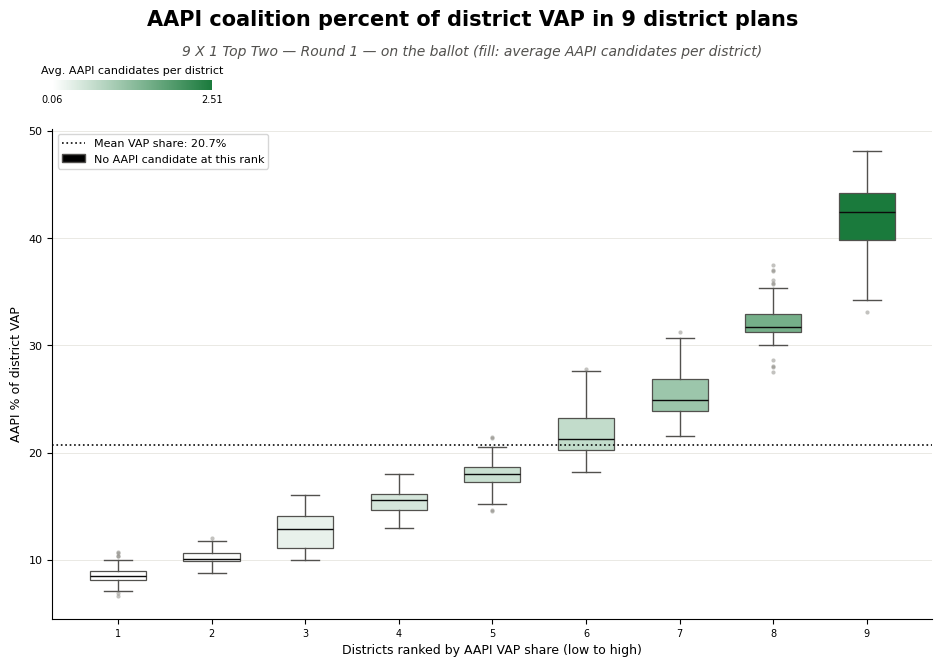

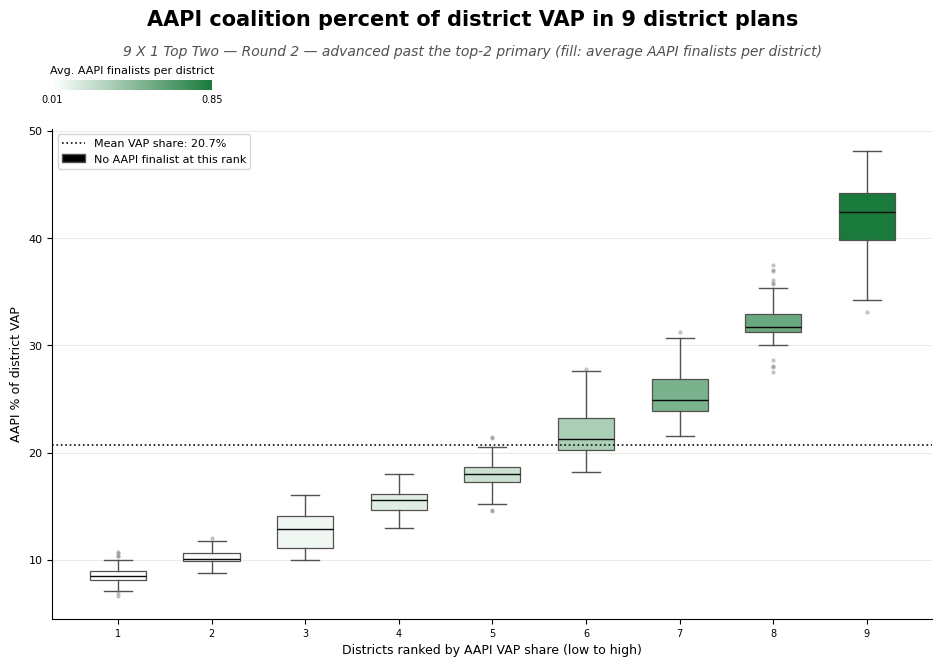

In [22]:
def round_metric_by_rank(num_dist, which):
    """
    (boxes, colour) for one round.

    which="round1" -> candidates on the ballot, straight from the settings files.
    which="round2" -> candidates surviving the primary, recomputed above.
    Both are averages per district at that rank, so the two figures share a unit.
    """
    vap_df = vap_by_count[num_dist]
    ranked = rank_districts(vap_df, FOCAL)
    if which == "round1":
        counts = avail_by_count[num_dist].rename(columns={"n_candidates": "value"})
    else:
        counts = finalists_by_count[num_dist].rename(columns={"n_finalists": "value"})

    merged = ranked[["plan", "district_id", "vap_rank", FOCAL]].merge(
        counts[["plan", "district_id", "value"]], on=["plan", "district_id"], how="inner"
    )
    data_by_rank = {
        r: (merged.loc[merged["vap_rank"] == r, FOCAL].to_numpy() * 100)
        for r in sorted(merged["vap_rank"].unique())
    }
    return data_by_rank, merged.groupby("vap_rank")["value"].mean()


# (round label, colorbar label, subtitle phrase) -- the subtitle phrase is spelled
# out rather than lower-casing the colorbar label, which would turn AAPI into aapi.
ROUND_WORDING = {
    "round1": (
        "Round 1 — on the ballot",
        f"Avg. {FOCAL} candidates per district",
        f"average {FOCAL} candidates per district",
    ),
    "round2": (
        f"Round 2 — advanced past the top-{M_1} primary",
        f"Avg. {FOCAL} finalists per district",
        f"average {FOCAL} finalists per district",
    ),
}


def plot_round_availability(num_dist, seats_per_district, which, save_dir=None):
    data_by_rank, value_by_rank = round_metric_by_rank(num_dist, which)
    if not data_by_rank:
        print("no data for", which)
        return None
    round_label, cbar_label, fill_phrase = ROUND_WORDING[which]

    fig = plt.figure(figsize=(max(10.0, len(data_by_rank) * 0.9), 7))
    ax = fig.add_axes((0.08, 0.10, 0.88, 0.70))
    draw_coalition_boxplot(
        ax, data_by_rank, value_by_rank, FOCAL,
        zero_case_label=(
            f"No {FOCAL} candidate at this rank" if which == "round1"
            else f"No {FOCAL} finalist at this rank"
        ),
    )
    fig.suptitle(
        f"{FOCAL} coalition percent of district VAP in {num_dist} district plans",
        fontsize=15, fontweight="bold", y=0.97,
    )
    system_label = _method_label(SYSTEM, num_dist, seats_per_district)
    fig.text(
        0.5, 0.90,
        f"{system_label} — {round_label} (fill: {fill_phrase})",
        ha="center", va="bottom", fontsize=10, color="#52514e", style="italic",
    )
    add_coalition_colorbar(
        fig, (0.08, 0.855, 0.16, 0.015), value_by_rank, label=cbar_label, tick_fmt="{:.2f}",
    )
    if save_dir is not None:
        save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
        out = save_dir / (
            f"{RUN_NAME}_{num_dist}x{seats_per_district}_{FOCAL}_{SYSTEM}_{which}_availability.png"
        )
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("wrote", out)
    return fig


for n, w in configs_in_run:
    for which in ("round1", "round2"):
        fig = plot_round_availability(n, w, which)
        if fig is not None:
            plt.show()

### What survives the primary

The two colour ramps answer different questions, so read the endpoints, not just
the shade. Round 1 counts who was willing and able to run; round 2 counts who the
electorate kept. The gap between them at a given rank is the primary's filter:
where round 2 falls well below round 1, AAPI candidates were on the ballot but
did not draw enough first choices to reach the final four.

In [23]:
def round_comparison(num_dist):
    _, r1 = round_metric_by_rank(num_dist, "round1")
    _, r2 = round_metric_by_rank(num_dist, "round2")
    out = pd.DataFrame({
        "mean_AAPI_vap_pct": rank_districts(vap_by_count[num_dist], FOCAL)
            .groupby("vap_rank")[FOCAL].mean() * 100,
        "round1_on_ballot": r1,
        "round2_finalists": r2,
    })
    out["kept_pct"] = (out["round2_finalists"] / out["round1_on_ballot"] * 100)
    return out.round(2)


for n, w in configs_in_run:
    print(f"=== {_method_label(SYSTEM, n, w)}: round 1 vs round 2 ===")
    print(round_comparison(n).to_string(), "\n")

=== 9 X 1 Top Two: round 1 vs round 2 ===
          mean_AAPI_vap_pct  round1_on_ballot  round2_finalists  kept_pct
vap_rank                                                                 
1                      8.54              0.06              0.01     24.17
2                     10.22              0.11              0.04     32.73
3                     12.66              0.31              0.07     22.74
4                     15.52              0.51              0.13     25.00
5                     18.00              0.64              0.20     31.48
6                     21.80              0.72              0.32     44.65
7                     25.24              1.12              0.50     44.46
8                     32.16              1.54              0.56     36.17
9                     41.92              2.51              0.85     33.76 



## Win-rate variant (Chicago's original reading)

Kept for the cases where the question is "did the slate actually win here". This
is the ported design unchanged: restricted to districts that had an AAPI
candidate, filled by win rate, and drawn per voting system, since the same
districts elect differently under each. Win rates pool both voter models.

Ranking still happens against every district in the plan *before* the restriction
is applied, so a rank number means the same district position in both sections —
thin ranks go missing rather than the rest sliding down to fill the gap.

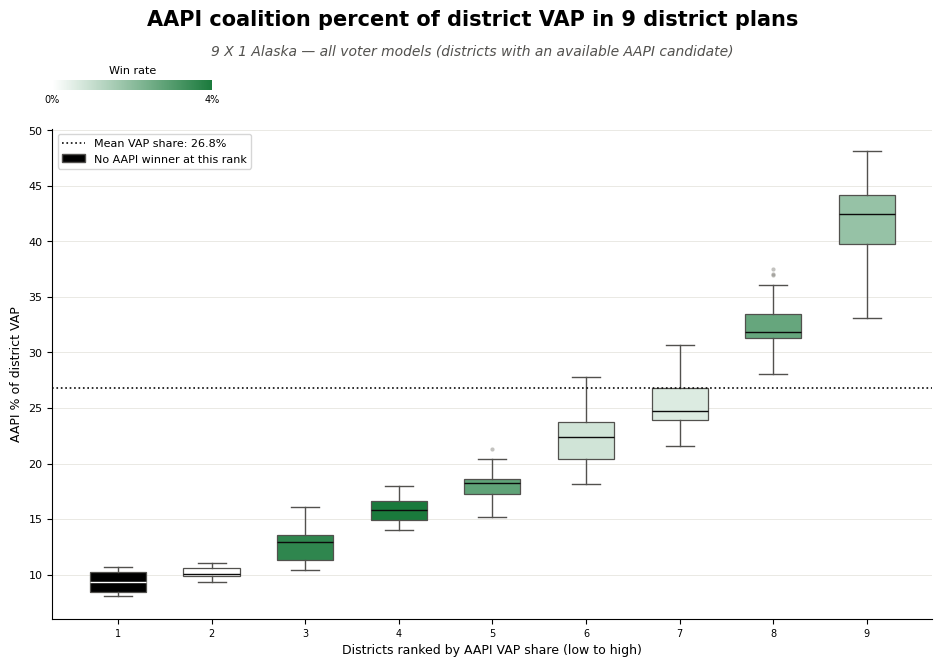

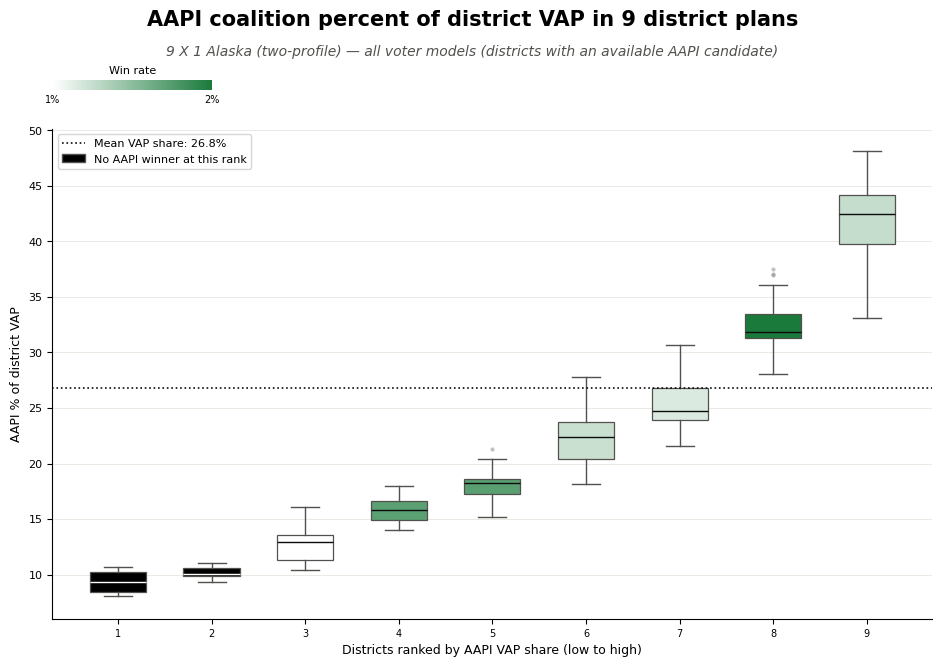

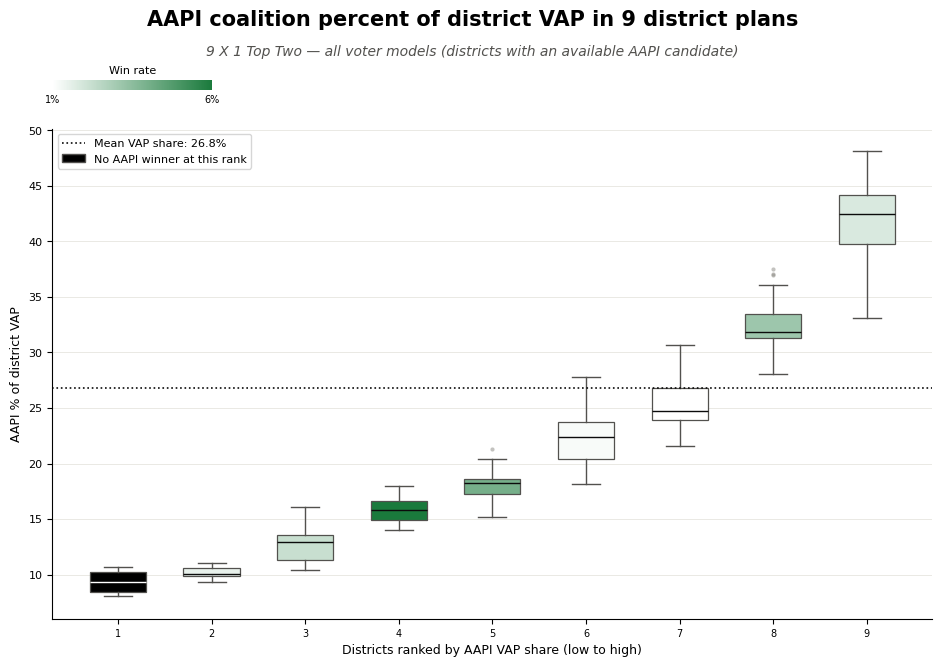

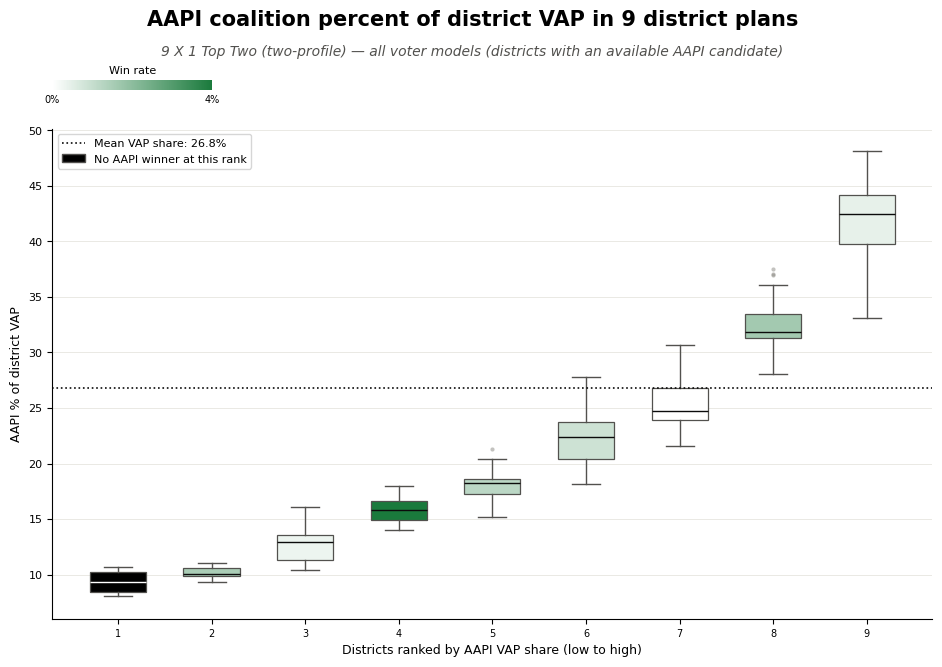

In [24]:
def plot_win_rate_boxplot(election_method, num_dist, seats_per_district, mode=None, save_dir=None):
    """Availability-restricted boxplot filled by win rate, for one voting system."""
    rows = summary[
        (summary["election_method"] == election_method)
        & (summary["num_districts"] == num_dist)
        & (summary["seats_per_district"] == seats_per_district)
    ]
    if mode is not None:
        rows = rows[rows["mode"] == mode]
    if rows.empty:
        print("no rows for", election_method)
        return None

    vap_df, avail_df = vap_by_count[num_dist], avail_by_count[num_dist]
    available_pairs = avail_df.loc[avail_df["has_candidate"], ["plan", "district_id"]]
    data_by_rank, win_rate_by_rank = rank_boxplot_data(
        rows, vap_df, FOCAL, restrict_to=available_pairs
    )
    if not data_by_rank:
        print("no VAP-share/winner data for", election_method)
        return None

    fig = plt.figure(figsize=(max(10.0, len(data_by_rank) * 0.9), 7))
    ax = fig.add_axes((0.08, 0.10, 0.88, 0.70))
    draw_coalition_boxplot(
        ax, data_by_rank, win_rate_by_rank, FOCAL,
        zero_case_label=f"No {FOCAL} winner at this rank",
    )
    fig.suptitle(
        f"{FOCAL} coalition percent of district VAP in {num_dist} district plans",
        fontsize=15, fontweight="bold", y=0.97,
    )
    model_note = "all voter models" if mode is None else f"{LEGEND_MAPPING.get(mode, mode)} model"
    fig.text(
        0.5, 0.90,
        f"{_method_label(election_method, num_dist, seats_per_district)} — {model_note} "
        f"(districts with an available {FOCAL} candidate)",
        ha="center", va="bottom", fontsize=10, color="#52514e", style="italic",
    )
    add_coalition_colorbar(fig, (0.08, 0.855, 0.16, 0.015), win_rate_by_rank, label="Win rate")

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out = Path(save_dir) / (
            f"{RUN_NAME}_{num_dist}x{seats_per_district}_{FOCAL}_coalition_boxplot_available.png"
        )
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("wrote", out)
    return fig


for n, w in configs_in_run:
    for method in systems:
        fig = plot_win_rate_boxplot(method, n, w)
        if fig is not None:
            plt.show()

## Write them out

Availability figures go to `figures/<run>/`, since they describe the run rather
than any one system; the win-rate figures go to `figures/<run>/<VOTING SYSTEM>/`,
beside the pipeline's per-system panels.

In [19]:
def write_all(save=True):
    written = []
    for n, w in configs_in_run:
        run_dir = PROJECT_DIR / "figures" / RUN_NAME if save else None
        fig = plot_availability_boxplot(n, w, save_dir=run_dir)
        if fig is not None:
            written.append(("availability", f"{n}x{w}")); plt.close(fig)
        for method in systems:
            method_dir = PROJECT_DIR / "figures" / RUN_NAME / method if save else None
            fig = plot_win_rate_boxplot(method, n, w, save_dir=method_dir)
            if fig is not None:
                written.append((method, "win rate")); plt.close(fig)
    print(f"\n{len(written)} figure(s) written")
    return written


# write_all()